## Looping Graph

### Objectives:

1. Implement looping logic to route the flow of data back to the nodes
2. Create a single conditional edge to handle decision-making and control graph flow

### Main Goal:
Coding up Looping Logic

In [17]:
from typing import TypedDict, Dict, List
from langgraph.graph import StateGraph, START, END
import random

In [18]:
class AgentState(TypedDict): 
    name: str
    number: List[int]
    counter: int

In [19]:
def greeting_node(state: AgentState) -> AgentState:
    """
    Node that greets, saying hi to the user
    """

    state["name"] = f"Hi, {state["name"]}"
    state["counter"] = 0

    return state

In [20]:
def random_node(state: AgentState) -> AgentState:
    """
    Create a random number from 0 to 10
    """

    state["number"].append(random.randint(0, 10))
    print("NEW NUM ADDED: ", state["number"])
    state["counter"] += 1

    return state

In [21]:
def should_continue(state: AgentState) -> AgentState: 
    """
    Decide whether to keep looping or exit 
    """

    if state["counter"] < 5:
        print("ENTERING LOOP", state["counter"])
        return "loop" # Continue looping
    else:
        return "exit" # Exit the loop

## The Process Order

Greeting -> random -> random -> random -> random -> random -> END

In [22]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)
graph.add_node("random", random_node)

graph.add_edge(START, "greeter")
graph.add_edge("greeter", "random")
graph.add_conditional_edges(
    source="random",
    path=should_continue,
    path_map={
        "loop": "random", #loop back to the same node(random_node)
        "exit": END # Exit and END the graph
    }
)

app = graph.compile()

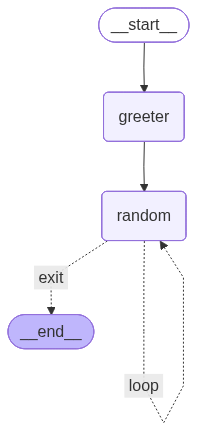

In [23]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
app.invoke(
    {
        "name": "MyungHwan", 
        "number": []
    }
)

NEW NUM ADDED:  [8]
ENTERING LOOP 1
NEW NUM ADDED:  [8, 2]
ENTERING LOOP 2
NEW NUM ADDED:  [8, 2, 7]
ENTERING LOOP 3
NEW NUM ADDED:  [8, 2, 7, 4]
ENTERING LOOP 4
NEW NUM ADDED:  [8, 2, 7, 4, 9]


{'name': 'Hi, MyungHwan', 'number': [8, 2, 7, 4, 9], 'counter': 5}